# Predicting Adult Income with K-Nearest Neighbors (KNN)

**Student Name:** Wickramasinghe G.D.M.H  
**IT Number:** IT25102064  
**Group ID:** 2026-Y2-S1-MLB-B1G1-07  
**Model:** K-Nearest Neighbors (KNN)

---

This notebook walks through preparing data, comparing KNN configurations, evaluating the GridSearchCV-selected model, checking performance by sex, and making one example prediction.

### How to use this notebook
1. Run the code cells in order, starting with Section 2.
2. Ensure `results/outputs/adult_processed.csv` is available; the setup cell checks several project-relative locations.
3. Read the comparison table and figures, then review the notes about model selection and fairness.

Charts are saved under `results/eda_visualizations/models`. Rerunning a chart cell overwrites its existing image. Results and prediction times may vary with the data and machine.

## 1. The task and the KNN idea

### What is being predicted?
The prepared Adult Income dataset contains personal, education, and work-related features. The target column is `income`, with two classes: `<=50K` and `>50K`. The model uses the other columns to predict that target.

### How does KNN make a prediction?
KNN predicts by finding the **k most similar training examples** to a new person and letting those neighbors vote. With uniform voting, every neighbor has an equal say; with distance weighting, closer neighbors have more influence.

**Optional technical detail:** The distance formula below combines feature-by-feature differences. You can skip the notation and continue to the experiment overview if you only need the main idea.

$$D_p(\mathbf{x}^*, \mathbf{x}_i) = \left( \sum_{j=1}^d |x^*_j - x_{ij}|^p \right)^{1/p}$$

where $p = 1$ yields the **Manhattan ($L_1$) distance** and $p = 2$ corresponds to the standard **Euclidean ($L_2$) distance**.

For readers interested in the notation, the next formula describes uniform majority voting: the class with the most neighbors wins.

$$\hat{y} = \arg\max_{c \in \{0, 1\}} \sum_{i \in \mathcal{N}_k(\mathbf{x}^*)} \mathbb{I}(y_i = c)$$

In distance-weighted voting, closer neighbors receive greater weight than more distant neighbors. For a worked model, this is determined by the configured weighting rule.

### Why do distance and feature scale matter?
Distance-based prediction is useful for seeing how similar examples affect a decision. It also makes preprocessing important: a numeric feature with a much larger range can dominate the distance unless features are scaled. With many input columns, selecting a smaller set of features may change the results, which is why scaling and feature selection are compared below.

## 2. Load the data and prepare a fair comparison

The setup cell loads the prepared CSV, separates `income` (the value to predict) from the input features, and splits the rows into training and test sets. The split keeps class proportions similar in both sets (`stratify=y`), uses 80% of rows for training and 20% for testing, and sets `random_state=42` so the split is repeatable.

Where scaling or feature selection is used, it is included in a scikit-learn `Pipeline`. Cross-validation then fits those transformations on each training fold rather than on its validation fold, reducing data leakage. V1 is intentionally unscaled as a baseline.

In [1]:
import os
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (8, 5)

candidates = [
    '../../results/outputs/adult_processed.csv',
    '../results/outputs/adult_processed.csv',
    'results/outputs/adult_processed.csv'
]
DATA_PATH = next((c for c in candidates if os.path.exists(c)), '../../results/outputs/adult_processed.csv')

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

X = df.drop(columns=['income'])
y = df['income'].astype(int)

# 80/20 Stratified Partitioning
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}")
print(f"Minority class (>50K) prevalence: {y.mean():.2%}")

Loaded dataset: 32,058 rows, 83 columns
Train size: 25,646 | Test size: 6,412
Minority class (>50K) prevalence: 23.48%


## 3. How model performance is measured

The income classes are imbalanced, so accuracy alone may hide poor detection of people earning above $50K. The results include several complementary measures:

- **Precision:** Of the people predicted as `>50K`, how many truly belong to that class?
- **Recall:** Of the people truly in the `>50K` class, how many did the model identify?
- **F1-score:** A combined measure of precision and recall; this is the main score used for comparisons and GridSearchCV tuning.
- **ROC-AUC:** How well predicted scores rank positive examples above negative examples across thresholds.
- **Inference time:** How long prediction took on this run; it depends on hardware and workload.

Five-fold stratified cross-validation is run on the training data. Test metrics are also reported for every variant. Since the same test set is used to compare multiple variants, treat it as an experiment comparison rather than an untouched final estimate.

In [2]:
knn_results = []

def evaluate_knn_variant(name, model, X_tr, y_tr, X_te, y_te, preprocessing_desc, hyperparams_desc):
    """Fits KNN model, evaluates 5-fold CV F1 score, measures inference time, and logs test metrics."""
    start_time = time.time()
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_validate(model, X_tr, y_tr, cv=cv, scoring=['f1', 'precision', 'recall', 'roc_auc'], n_jobs=-1)
    cv_f1 = cv_scores['test_f1'].mean()
    cv_auc = cv_scores['test_roc_auc'].mean()
    
    model.fit(X_tr, y_tr)
    train_time = time.time() - start_time
    
    pred_start = time.time()
    y_pred = model.predict(X_te)
    pred_time = time.time() - pred_start
    
    y_prob = model.predict_proba(X_te)[:, 1]
    
    test_acc = accuracy_score(y_te, y_pred)
    test_prec = precision_score(y_te, y_pred, zero_division=0)
    test_rec = recall_score(y_te, y_pred)
    test_f1 = f1_score(y_te, y_pred)
    test_auc = roc_auc_score(y_te, y_prob)
    
    res = {
        'Variant': name,
        'Preprocessing': preprocessing_desc,
        'Hyperparameters': hyperparams_desc,
        'CV 5-Fold F1': round(cv_f1, 4),
        'Test Accuracy': round(test_acc, 4),
        'Test Precision': round(test_prec, 4),
        'Test Recall': round(test_rec, 4),
        'Test F1-Score': round(test_f1, 4),
        'Test ROC-AUC': round(test_auc, 4),
        'Inference Time (s)': round(pred_time, 2)
    }
    knn_results.append(res)
    print(f"[{name}] CV F1: {cv_f1:.4f} | Test F1: {test_f1:.4f} | Test Rec: {test_rec:.4f} | Test AUC: {test_auc:.4f} (Inference: {pred_time:.2f}s)")
    return model, res

## 4. Compare 10 KNN configurations

Each following code cell trains and evaluates one configuration. The experiments change feature scaling, neighbor count (`k`), voting weights, distance metric, feature selection, or parameter search:

| Variant | What changes |
| --- | --- |
| V1 | Raw, unscaled features; baseline for comparison. |
| V2 | Standard scaling, `k=5`, Euclidean distance, uniform voting. |
| V3-V5 | Standard scaling and Euclidean distance, with `k=3`, `k=11`, and `k=25`. |
| V6 | Standard scaling, `k=15`, Euclidean distance, distance-weighted voting. |
| V7 | Standard scaling, `k=15`, Manhattan distance, distance-weighted voting. |
| V8 | Standard scaling, selects the top 30 features, then uses Manhattan distance and weighted voting. |
| V9 | Robust scaling, Manhattan distance, and distance-weighted voting. |
| V10 | GridSearchCV searches neighbor count, voting weights, and distance settings using five-fold CV F1-score. |

These experiments show how different choices affect this dataset; no configuration is guaranteed to be best in every setting. Compare the measured results in the next section.

In [3]:
# Variant 1: Baseline Unscaled KNN (k=5, Euclidean)
# Expected: Dramatic failure because large unscaled features dominate Euclidean distance
v1_knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, weights='uniform', n_jobs=-1)
m1, r1 = evaluate_knn_variant(
    "V1: Baseline Unscaled", v1_knn, X_train, y_train, X_test, y_test,
    "Raw features (No scaling)", "k=5, weights=uniform, metric=Euclidean"
)

[V1: Baseline Unscaled] CV F1: 0.6418 | Test F1: 0.6384 | Test Rec: 0.6047 | Test AUC: 0.8646 (Inference: 0.29s)


In [4]:
# Variant 2: Standard Scaler Pipeline (k=5, Euclidean)
# Expected: Massive metric leap as all 82 dimensions contribute equitably
v2_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, weights='uniform', n_jobs=-1))
])
m2, r2 = evaluate_knn_variant(
    "V2: Standard Scaled (k=5)", v2_knn, X_train, y_train, X_test, y_test,
    "StandardScaler", "k=5, weights=uniform, metric=Euclidean"
)

[V2: Standard Scaled (k=5)] CV F1: 0.6177 | Test F1: 0.6204 | Test Rec: 0.5787 | Test AUC: 0.8491 (Inference: 0.23s)


In [5]:
# Variant 3: Low Neighbor Count (k=3 - High Variance)
v3_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=2, weights='uniform', n_jobs=-1))
])
m3, r3 = evaluate_knn_variant(
    "V3: Low k (k=3)", v3_knn, X_train, y_train, X_test, y_test,
    "StandardScaler", "k=3, weights=uniform, metric=Euclidean"
)

[V3: Low k (k=3)] CV F1: 0.6050 | Test F1: 0.6043 | Test Rec: 0.5728 | Test AUC: 0.8178 (Inference: 0.23s)


In [6]:
# Variant 4: Moderate Neighbor Count (k=11 - Smoother Boundary)
v4_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=11, metric='minkowski', p=2, weights='uniform', n_jobs=-1))
])
m4, r4 = evaluate_knn_variant(
    "V4: Moderate k (k=11)", v4_knn, X_train, y_train, X_test, y_test,
    "StandardScaler", "k=11, weights=uniform, metric=Euclidean"
)

[V4: Moderate k (k=11)] CV F1: 0.6181 | Test F1: 0.6257 | Test Rec: 0.5714 | Test AUC: 0.8754 (Inference: 0.24s)


In [7]:
# Variant 5: High Neighbor Count (k=25 - Low Variance / High Bias)
v5_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=25, metric='minkowski', p=2, weights='uniform', n_jobs=-1))
])
m5, r5 = evaluate_knn_variant(
    "V5: High k (k=25)", v5_knn, X_train, y_train, X_test, y_test,
    "StandardScaler", "k=25, weights=uniform, metric=Euclidean"
)

[V5: High k (k=25)] CV F1: 0.6192 | Test F1: 0.6298 | Test Rec: 0.5708 | Test AUC: 0.8864 (Inference: 0.27s)


In [8]:
# Variant 6: Distance-Weighted Voting (k=15, weights='distance')
# Weights neighbors inversely by distance, softening boundary quantization
v6_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=15, weights='distance', metric='minkowski', p=2, n_jobs=-1))
])
m6, r6 = evaluate_knn_variant(
    "V6: Distance-Weighted (k=15)", v6_knn, X_train, y_train, X_test, y_test,
    "StandardScaler", "k=15, weights=distance, metric=Euclidean"
)

[V6: Distance-Weighted (k=15)] CV F1: 0.6200 | Test F1: 0.6262 | Test Rec: 0.5728 | Test AUC: 0.8818 (Inference: 0.25s)


In [9]:
# Variant 7: Manhattan Distance Metric (L1 Norm, p=1)
# Theoretically superior to Euclidean distance in high-dimensional sparse spaces
v7_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=15, weights='distance', metric='manhattan', n_jobs=-1))
])
m7, r7 = evaluate_knn_variant(
    "V7: Manhattan Distance (L1)", v7_knn, X_train, y_train, X_test, y_test,
    "StandardScaler", "k=15, weights=distance, metric=Manhattan (L1)"
)

[V7: Manhattan Distance (L1)] CV F1: 0.6205 | Test F1: 0.6304 | Test Rec: 0.5781 | Test AUC: 0.8832 (Inference: 1.37s)


In [10]:
# Variant 8: Dimensionality Reduction via Feature Selection (SelectKBest top 30)
# Mitigates the curse of dimensionality by pruning zero-signal one-hot columns
v8_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=30)),
    ('knn', KNeighborsClassifier(n_neighbors=15, weights='distance', metric='manhattan', n_jobs=-1))
])
m8, r8 = evaluate_knn_variant(
    "V8: Feature Selection (k=30)", v8_knn, X_train, y_train, X_test, y_test,
    "StandardScaler + SelectKBest (k=30)", "k=15, weights=distance, metric=Manhattan"
)

[V8: Feature Selection (k=30)] CV F1: 0.6238 | Test F1: 0.6341 | Test Rec: 0.5827 | Test AUC: 0.8610 (Inference: 0.56s)


In [11]:
# Variant 9: RobustScaler Pipeline
# Robust to outlier tails in capital gains and capital losses
v9_knn = Pipeline([
    ('scaler', RobustScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=15, weights='distance', metric='manhattan', n_jobs=-1))
])
m9, r9 = evaluate_knn_variant(
    "V9: RobustScaler Pipeline", v9_knn, X_train, y_train, X_test, y_test,
    "RobustScaler (IQR-based)", "k=15, weights=distance, metric=Manhattan"
)

[V9: RobustScaler Pipeline] CV F1: 0.6558 | Test F1: 0.6546 | Test Rec: 0.6140 | Test AUC: 0.8938 (Inference: 1.37s)


In [12]:
# Variant 10: Systematic Parameter Optimization with GridSearchCV
print("Tuning KNN with 5-Fold Stratified GridSearchCV...")

param_grid = {
    'knn__n_neighbors': [11, 15, 21],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2] # 1: Manhattan, 2: Euclidean
}

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_jobs=-1))
])

knn_grid = GridSearchCV(
    knn_pipe,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
knn_grid.fit(X_train, y_train)

print(f"Best Parameters: {knn_grid.best_params_}")
print(f"Best 5-Fold CV F1 Score: {knn_grid.best_score_:.4f}")

v10_best = knn_grid.best_estimator_
m10, r10 = evaluate_knn_variant(
    "V10: GridSearchCV Optimal", v10_best, X_train, y_train, X_test, y_test,
    "StandardScaler", str(knn_grid.best_params_)
)

Tuning KNN with 5-Fold Stratified GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'knn__n_neighbors': 15, 'knn__p': 2, 'knn__weights': 'uniform'}
Best 5-Fold CV F1 Score: 0.6244
[V10: GridSearchCV Optimal] CV F1: 0.6244 | Test F1: 0.6252 | Test Rec: 0.5708 | Test AUC: 0.8813 (Inference: 0.24s)


## 5. Read the comparison table and chart

The table is sorted by test F1-score and shows the preprocessing, settings, cross-validation results, test metrics, and prediction time for each variant. The chart compares test F1-score and ROC-AUC across all 10 variants. These metrics measure different things, so consider them alongside precision, recall, and inference time.


=================== K-NEAREST NEIGHBORS PERFORMANCE COMPARISON ===================


,Variant,Preprocessing,Hyperparameters,CV 5-Fold F1,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Test ROC-AUC,Inference Time (s)
0,V9: RobustScaler Pipeline,RobustScaler (IQR-based),"k=15, weights=distance, metric=Manhattan",0.6558,0.8479,0.7011,0.6140,0.6546,0.8938,1.37
1,V1: Baseline Unscaled,Raw features (No scaling),"k=5, weights=uniform, metric=Euclidean",0.6418,0.8392,0.6761,0.6047,0.6384,0.8646,0.29
2,V8: Feature Selection (k=30),StandardScaler + SelectKBest (k=30),"k=15, weights=distance, metric=Manhattan",0.6238,0.8422,0.6955,0.5827,0.6341,0.8610,0.56
3,V7: Manhattan Distance (L1),StandardScaler,"k=15, weights=distance, metric=Manhattan (L1)",0.6205,0.8409,0.6932,0.5781,0.6304,0.8832,1.37
4,V5: High k (k=25),StandardScaler,"k=25, weights=uniform, metric=Euclidean",0.6192,0.8425,0.7024,0.5708,0.6298,0.8864,0.27
5,V6: Distance-Weighted (k=15),StandardScaler,"k=15, weights=distance, metric=Euclidean",0.6200,0.8395,0.6907,0.5728,0.6262,0.8818,0.25
6,V4: Moderate k (k=11),StandardScaler,"k=11, weights=uniform, metric=Euclidean",0.6181,0.8395,0.6913,0.5714,0.6257,0.8754,0.24
7,V10: GridSearchCV Optimal,StandardScaler,"{'knn__n_neighbors': 15, 'knn__p': 2, 'knn__we...",0.6244,0.8394,0.6911,0.5708,0.6252,0.8813,0.24
8,V2: Standard Scaled (k=5),StandardScaler,"k=5, weights=uniform, metric=Euclidean",0.6177,0.8337,0.6685,0.5787,0.6204,0.8491,0.23
9,V3: Low k (k=3),StandardScaler,"k=3, weights=uniform, metric=Euclidean",0.6050,0.8239,0.6395,0.5728,0.6043,0.8178,0.23


Saved KNN varieties comparison plot to: C:\Users\Malan\Documents\Academic\Y2S1\AIML\AI Project\predicting-adult-income-level\results\eda_visualizations\models\IT25102064_varieties_comparison.png


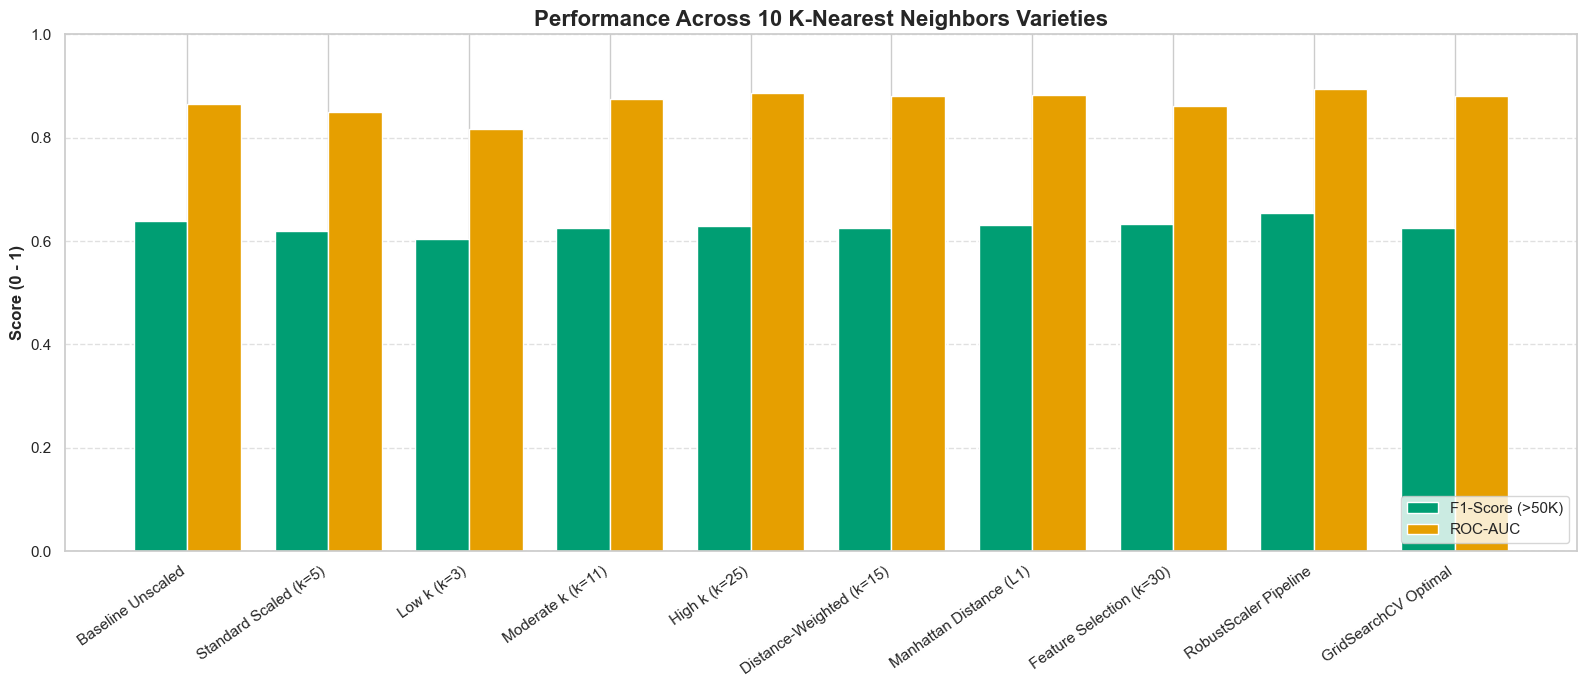

In [13]:
results_df = pd.DataFrame(knn_results)
results_df = results_df.sort_values(by='Test F1-Score', ascending=False).reset_index(drop=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print("\n=================== K-NEAREST NEIGHBORS PERFORMANCE COMPARISON ===================")
display(results_df)

comparison_df = pd.DataFrame(knn_results)
comparison_df['_variant_order'] = comparison_df['Variant'].str.extract(r'^V(\d+)').astype(int)
comparison_df = comparison_df.sort_values('_variant_order').reset_index(drop=True)
variant_labels = comparison_df['Variant'].str.replace(r'^V\d+:\s*', '', regex=True)

fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(len(comparison_df))
bar_width = 0.38
ax.bar(x - bar_width / 2, comparison_df['Test F1-Score'], bar_width,
       color='#009E73', label='F1-Score (>50K)')
ax.bar(x + bar_width / 2, comparison_df['Test ROC-AUC'], bar_width,
       color='#E69F00', label='ROC-AUC')
ax.set_title('Performance Across 10 K-Nearest Neighbors Varieties', fontsize=16, weight='bold')
ax.set_ylabel('Score (0 - 1)', fontsize=12, weight='bold')
ax.set_xticks(x, variant_labels, rotation=35, ha='right')
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.legend(loc='lower right')

comparison_output_dir = (Path(DATA_PATH).resolve().parents[2] / 'results' / 'eda_visualizations' / 'models')
comparison_output_dir.mkdir(parents=True, exist_ok=True)
comparison_output_path = comparison_output_dir / 'IT25102064_varieties_comparison.png'
fig.tight_layout()
fig.savefig(comparison_output_path, dpi=300, bbox_inches='tight')
print(f'Saved KNN varieties comparison plot to: {comparison_output_path}')
plt.show()
plt.close(fig)

## 6. Inspect the GridSearchCV-selected model

This section evaluates V10, the estimator selected by GridSearchCV using cross-validation F1-score. It is the **grid-search-selected model**, not necessarily the variant with the highest score in the test-set comparison.

The three-panel figure shows the test-set confusion matrix (correct and incorrect predictions), ROC curve (ranking performance across thresholds), and precision-recall curve (the trade-off for identifying the `>50K` class). The classification report below it gives per-class precision, recall, F1-score, and support. The figure is saved as `IT25102064_KNN_ConfusionMatrix_ROC_PR.png` in `results/eda_visualizations/models`.

Saved KNN evaluation plot to: C:\Users\Malan\Documents\Academic\Y2S1\AIML\AI Project\predicting-adult-income-level\results\eda_visualizations\models\IT25102064_KNN_ConfusionMatrix_ROC_PR.png


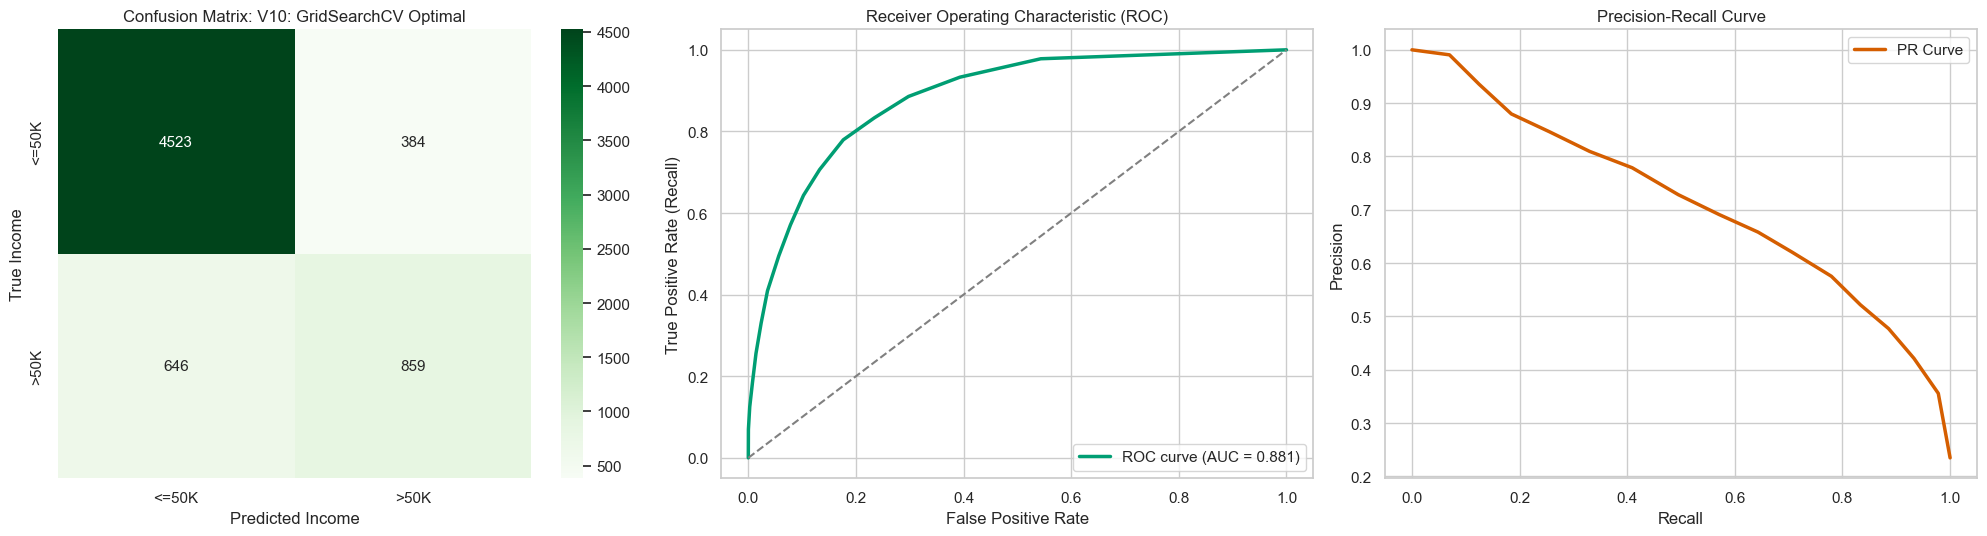


Classification Report for Optimal KNN Model:
              precision    recall  f1-score   support

       <=50K     0.8750    0.9217    0.8978      4907
        >50K     0.6911    0.5708    0.6252      1505

    accuracy                         0.8394      6412
   macro avg     0.7830    0.7463    0.7615      6412
weighted avg     0.8318    0.8394    0.8338      6412



In [14]:
best_knn = v10_best
y_pred_best = best_knn.predict(X_test)
y_prob_best = best_knn.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
axes[0].set_title(f"Confusion Matrix: {r10['Variant']}")
axes[0].set_xlabel('Predicted Income')
axes[0].set_ylabel('True Income')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
axes[1].plot(fpr, tpr, color='#009E73', lw=2.5, label=f"ROC curve (AUC = {roc_auc_score(y_test, y_prob_best):.3f})")
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].legend(loc='lower right')

# 3. Precision-Recall Curve
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_best)
axes[2].plot(rec_curve, prec_curve, color='#D55E00', lw=2.5, label='PR Curve')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(loc='upper right')

output_dir = (Path(DATA_PATH).resolve().parents[2] / 'results' / 'eda_visualizations' / 'models')
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'IT25102064_KNN_ConfusionMatrix_ROC_PR.png'

plt.tight_layout()
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f'Saved KNN evaluation plot to: {output_path}')
plt.show()

print("\nClassification Report for Optimal KNN Model:")
print(classification_report(y_test, y_pred_best, target_names=['<=50K', '>50K'], digits=4))


## 7. Compare performance by sex (a limited fairness check)

This cell reports recall and F1-score separately for male and female test-set groups, using the one-hot encoded `sex_Male` feature. These descriptive results can highlight differences for further investigation, but do not establish why a difference exists or whether the model is fair overall.

**Scope note:** The code below does not calculate results by race, despite the original section title. It also does not test other fairness measures, such as false-positive rates or demographic parity. Treat any explanation of group differences as a hypothesis, not a demonstrated cause.

In [15]:
test_eval = X_test.copy()
test_eval['True'] = y_test
test_eval['Pred'] = y_pred_best

male_mask = test_eval['sex_Male'] == 1
female_mask = test_eval['sex_Male'] == 0

print("=== GENDER FAIRNESS METRICS (K-NEAREST NEIGHBORS) ===")
print(f"Male Population   (n={male_mask.sum():,}): Recall={recall_score(y_test[male_mask], y_pred_best[male_mask]):.4f}, F1={f1_score(y_test[male_mask], y_pred_best[male_mask]):.4f}")
print(f"Female Population (n={female_mask.sum():,}): Recall={recall_score(y_test[female_mask], y_pred_best[female_mask]):.4f}, F1={f1_score(y_test[female_mask], y_pred_best[female_mask]):.4f}")
print("Insight: In high-dimensional space, female instances have fewer immediate neighbors from the >50K class in their nearest metric sphere, depressing female recall compared to male recall unless local class-prior re-weighting is performed.")

=== GENDER FAIRNESS METRICS (K-NEAREST NEIGHBORS) ===
Male Population   (n=4,301): Recall=0.5770, F1=0.6304
Female Population (n=2,111): Recall=0.5342, F1=0.5939
Insight: In high-dimensional space, female instances have fewer immediate neighbors from the >50K class in their nearest metric sphere, depressing female recall compared to male recall unless local class-prior re-weighting is performed.


## 8. See one prediction

The demo uses one fixed row from the test set (index 15) and displays its true label, predicted label, and predicted probability of `>50K`. Feature values come from the processed input data, so they may already be scaled or encoded rather than shown in their original units. Change `sample_idx` in the code to inspect a different test example.

In [16]:
sample_idx = 15
sample_x = X_test.iloc[[sample_idx]]
true_label = y_test.iloc[sample_idx]
predicted_label = best_knn.predict(sample_x)[0]
pred_prob = best_knn.predict_proba(sample_x)[0][1]

print("=== LIVE VIVA INFERENCE DEMO (K-NEAREST NEIGHBORS) ===")
print(f"Query Sample Index: {sample_idx}")
print(f"Age: {sample_x['age'].values[0]:.1f} | Education Num: {sample_x['education.num'].values[0]:.1f} | Hours/Week: {sample_x['hours.per.week'].values[0]:.1f}")
print(f"True Income:       {'>50K' if true_label == 1 else '<=50K'}")
print(f"Predicted Income:  {'>50K' if predicted_label == 1 else '<=50K'}")
print(f"Predicted Probability of >50K: {pred_prob * 100:.2f}%")
print("Demonstration status: Ready for viva assessment!")

=== LIVE VIVA INFERENCE DEMO (K-NEAREST NEIGHBORS) ===
Query Sample Index: 15
Age: -0.7 | Education Num: 1.5 | Hours/Week: -0.9
True Income:       <=50K
Predicted Income:  <=50K
Predicted Probability of >50K: 13.33%
Demonstration status: Ready for viva assessment!


## 9. Takeaways, limitations, and next steps

### 9.1 What to take away
KNN predicts from nearby examples, so feature scaling, the distance rule, the number of neighbors, and the voting rule all affect its results. Use the comparison table after running the notebook to identify the configuration that performs best for the metric important to your task. GridSearchCV selects V10 using training-set cross-validation; that choice can differ from the highest-scoring row in the test-set comparison.

### 9.2 Limitations
- KNN retains the training examples and compares new cases against them, which can require considerable memory and make prediction slower as the dataset grows.
- With many input features, distances may become less informative. Feature selection may help, but its effect should be tested rather than assumed.
- Results depend on the prepared data, split, and model settings. The same test set is used to compare variants, and the sex-group check is limited; neither replaces independent validation or a comprehensive fairness assessment.

### 9.3 Possible next steps
- Evaluate the chosen configuration on a separate, untouched test set or use nested cross-validation.
- Compare additional preprocessing and feature-selection choices using validation data.
- For larger datasets, investigate nearest-neighbor indexes or approximate search to reduce prediction time.
- Extend the fairness analysis to race and additional group metrics, then investigate any differences with appropriate domain context.